In [1]:
import base64
import json
from pathlib import Path
import requests
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [5]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [9]:
SERVER_URL = "http://localhost:8000/sam3/segment"
IMAGE_PATH = "test_01.jpg"         
JSON_PATH = "test_01.json"

def load_meta(meta_path: Path) -> dict:
    return json.loads(meta_path.read_text(encoding="utf-8"))

# -----------------------
# SEND REQUEST
# -----------------------
json_metadata = load_meta(Path(JSON_PATH))
with open(IMAGE_PATH, "rb") as f:
    files = {
        "image": ("test_01.jpg", f, "image/jpeg"),
    }
    data = {
        "payload": json.dumps(json_metadata)
    }

    print("[CLIENT] Sending request...")
    resp = requests.post(SERVER_URL, files=files, data=data, timeout=120)

if resp.status_code != 200:
    print("[CLIENT] Request failed!")
    print(resp.status_code, resp.text)
    raise SystemExit(1)

result = resp.json()
# print("[CLIENT] Num instances:", result["returned"])


[CLIENT] Sending request...


IndexError: too many indices for array: array is 0-dimensional, but 1 were indexed

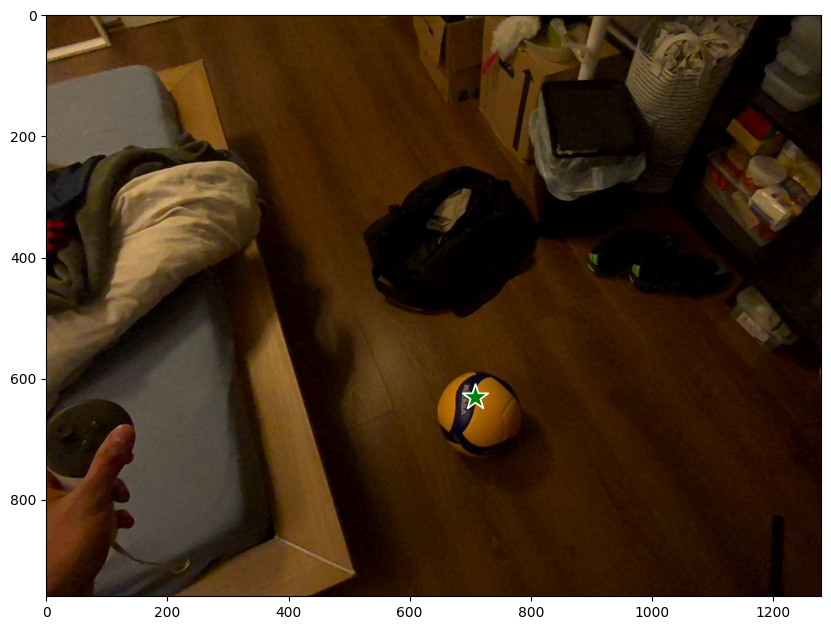

In [7]:

# -----------------------
# LOAD ORIGINAL IMAGE
# -----------------------
image = Image.open(IMAGE_PATH).convert("RGB")
input_point = np.asarray(json_metadata['point_prompt']['points'])
input_label = np.asarray(json_metadata['point_prompt']['labels'])
mask = np.asarray(result['mask_png'])

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
show_mask(mask[0], plt.gca(), borders=True)
plt.axis('on')
plt.show()